In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.filters as filters

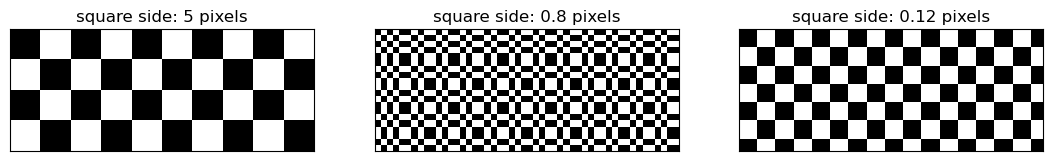

In [4]:
def chessboard(shape, square_size):
    img = np.indices(shape)   # Indices
    img = img // square_size  # Division entière : [0 0 0 1 1 1 2 2 2 3 3 3 ...]
    img = img.sum(axis=0)     # Somme les deux bandes
    img = img % 2             # Modulo : [0 0 0 1 1 1 0 0 0 1 1 1 ...]
    return img

def chessboard2(shape, square_size):
    L = 100
    (N,M) = np.dot(shape,L)
    C = square_size*L    
    img = np.indices((N,M))
    img = img // C
    img = img.sum(axis=0)
    img = img % 2
    img = filters.gaussian(img, sigma=10)
    img = img[0::L,0::L]
    return img

# Taille de l'image
N, M = 20,50

# Tailles des carrés
C = [5, .8, .12]

# Affichage
Z = 1.5
fig, axs = plt.subplots(1,len(C), figsize=(N/Z,M*3/Z))
for k in range(len(C)):
    img = chessboard((N,M),C[k])
    axs[k].imshow(img, "gray")
    axs[k].set_title(f"square side: {C[k]} pixels")
    axs[k].set_xticks([])
    axs[k].set_yticks([])

# Save and show
plt.savefig("square-aliasing.svg", transparent=True, bbox_inches="tight")
plt.show()